In [1]:
# importing libraries  
import os
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


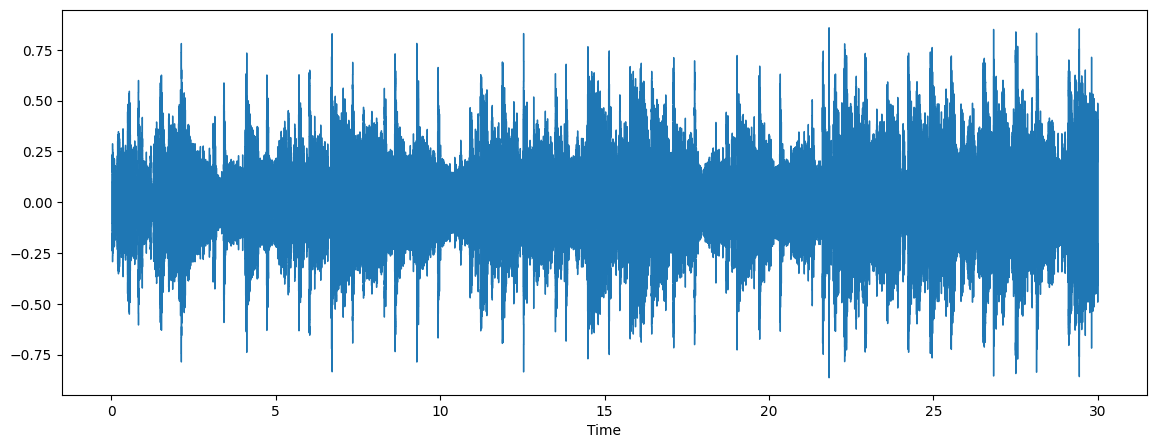

In [4]:
file_name = "/content/drive/MyDrive/music_genre_classification/genres_original/pop/pop.00003.wav"
y, sr = librosa.load(file_name, sr = 44100)
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)

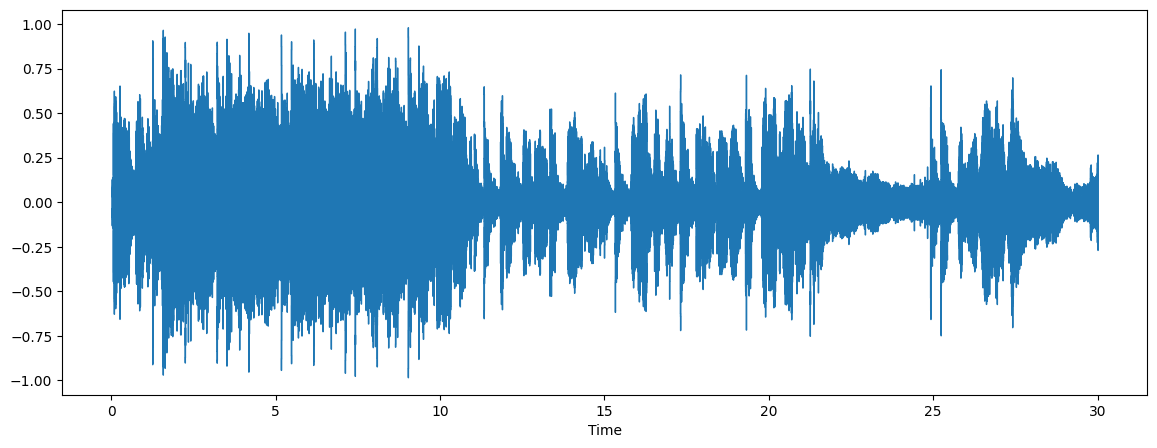

In [5]:
file_name = "/content/drive/MyDrive/music_genre_classification/genres_original/rock/rock.00000.wav"
y, sr = librosa.load(file_name, sr = 44100)
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)

In [6]:
y.shape

(1323588,)

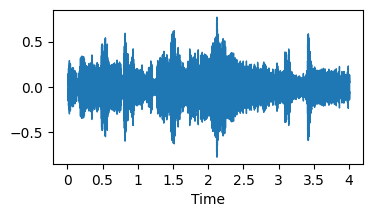

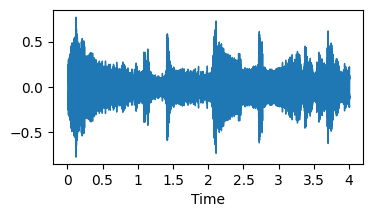

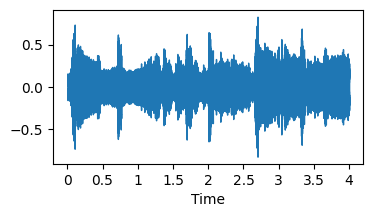

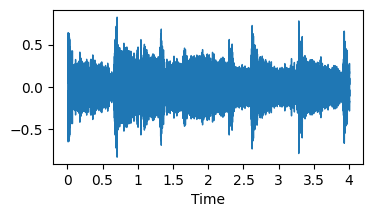

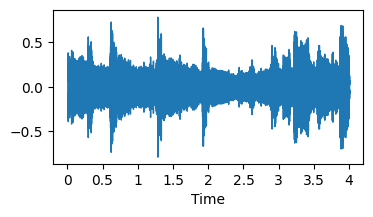

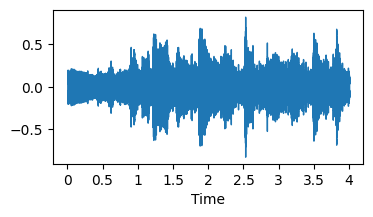

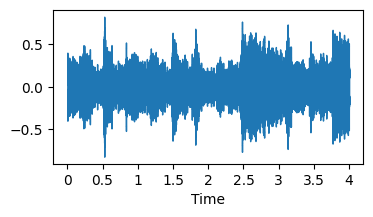

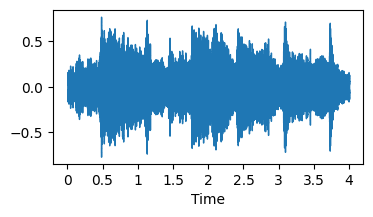

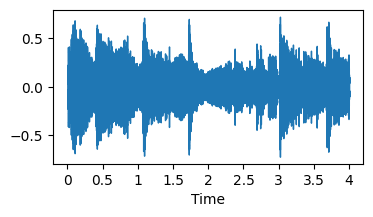

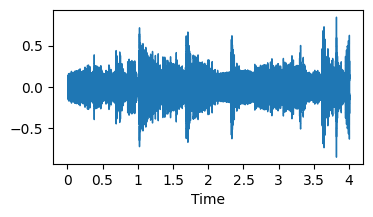

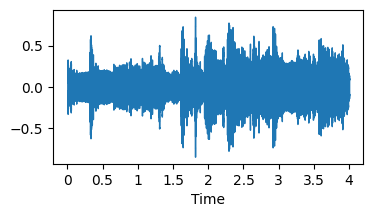

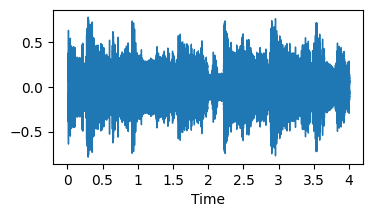

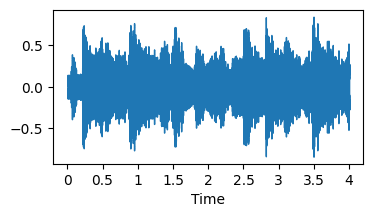

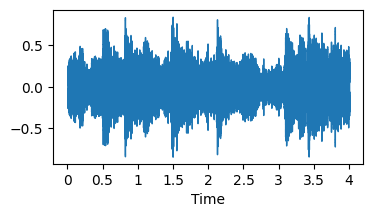

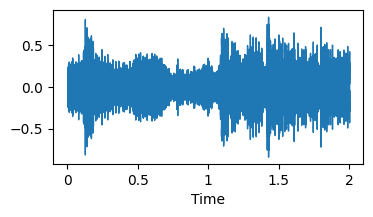

In [ ]:
#doing visualization on chunks of audio
audio_path = "/content/drive/MyDrive/music_genre_classification/genres_original/pop/pop.00003.wav"
# audio_path = "./pop.00003.wav"
y, sr = librosa.load(audio_path, sr = None) #load the audio file with its original sampling rate
# Define the duration of each chunk and overlap
chunk_duration = 4  # duration of each chunk in seconds
overlap_duration = 2  # overlap duration in seconds
#convert durations to samples
chunk_samples = chunk_duration * sr
overlap_samples = overlap_duration * sr
#calculate the number of chunks
num_chunks = int(np.ceil((len(y) - chunk_samples) / (chunk_samples - overlap_samples)))+1
#interate over the chunks
for i in range(num_chunks):
    #calculate the start and end sample indices for the current chunk
    start = i * (chunk_samples - overlap_samples)
    end = start + chunk_samples
    #extra the chunk audio
    chunk = y[start:end]
    plt.figure(figsize =(4,2))
    librosa.display.waveshow(chunk, sr=sr)
    plt.show()

In [ ]:
#Mel spectrogram visualization
#plotting melspectrogram of entire audio
def plot_melspectrogram(y,sr):
    #compute melspectrogram
    spectrogram = librosa.feature.melspectrogram(y=y, sr=sr) #step234:stft,spectrogram,mel scale
    #convert to decibels (log scale)
    # spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)
    spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)
    #visualize the spectrogram
    plt.figure(figsize=(10,4))
    librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%2.0f dB')
    plt.title("Spectrogram")
    plt.tight_layout()
    plt.show()

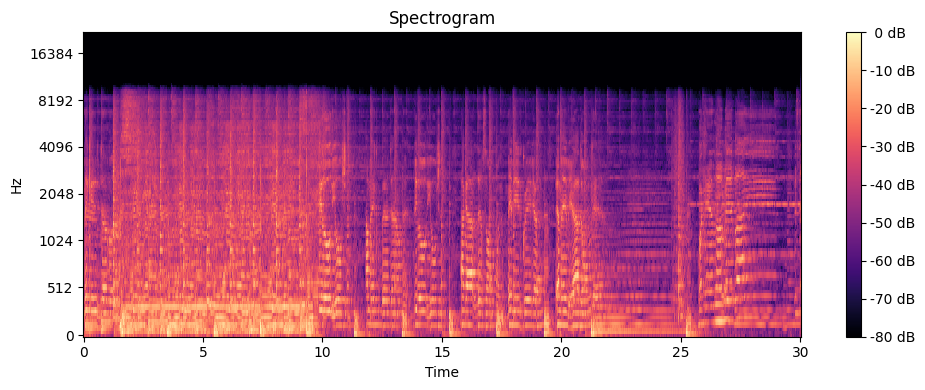

In [8]:
file_name = "./rock.00000.wav"
y,sr = librosa.load(file_name, sr=44100)
plot_melspectrogram(y,sr)

In [ ]:
def plot_melspectrograms_chunk(y,sr):
    chunk_duration = 4  # duration of each chunk in seconds
    overlap_duration = 2  # overlap duration in seconds

    #convert durations to samples
    chunk_samples = chunk_duration * sr
    overlap_samples = overlap_duration * sr
    #calculate the number of chunks
    num_chunks = int(np.ceil((len(y) - chunk_samples) / (chunk_samples - overlap_samples)))+1
    #interate over the chunks
    for i in range(num_chunks):
        #calculate the start and end sample indices for the current chunk
        start = i * (chunk_samples - overlap_samples)
        end = start + chunk_samples
        #extra the chunk audio
        chunk = y[start:end]
        #melspectrogram part
        spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sr)#step234:stft,spectrogram,mel scale
        print(spectrogram.shape)
        spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)
        #visualize the spectrogram
        plt.figure(figsize=(10,4))
        librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format='%2.0f dB')
        plt.title("Spectrogram")
        plt.tight_layout()
        plt.show()

(128, 345)


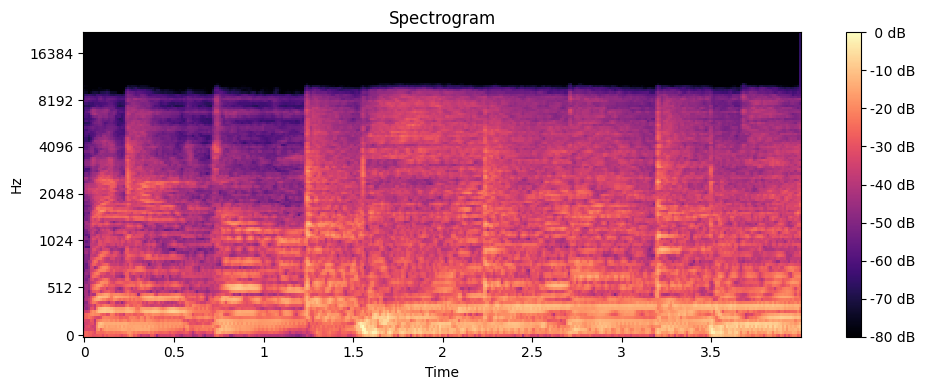

(128, 345)


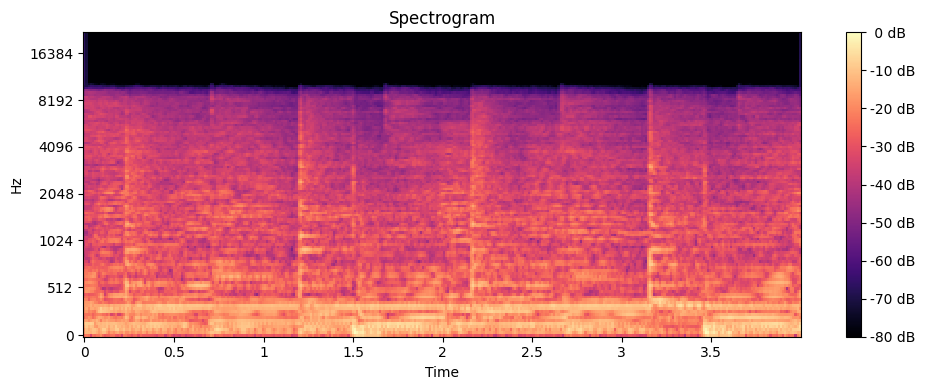

(128, 345)


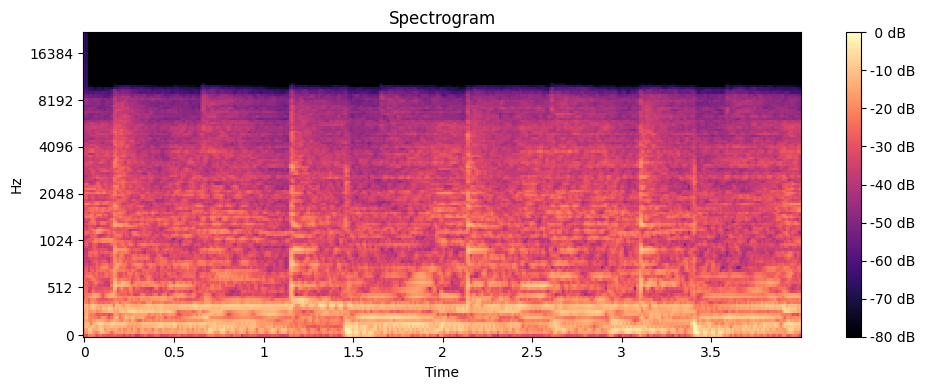

(128, 345)


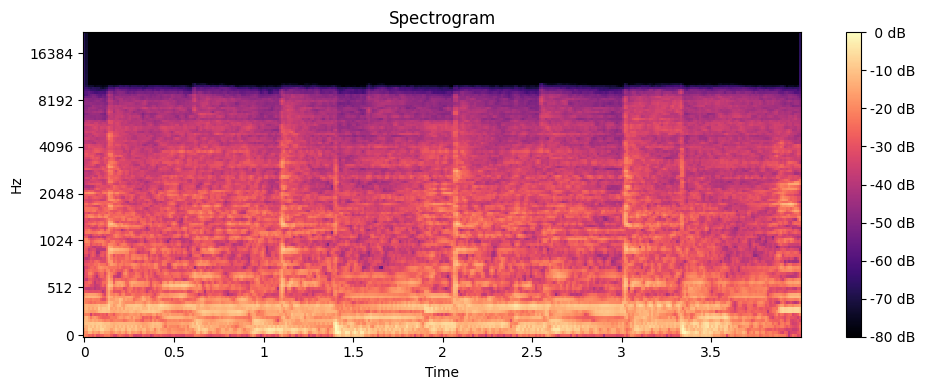

(128, 345)


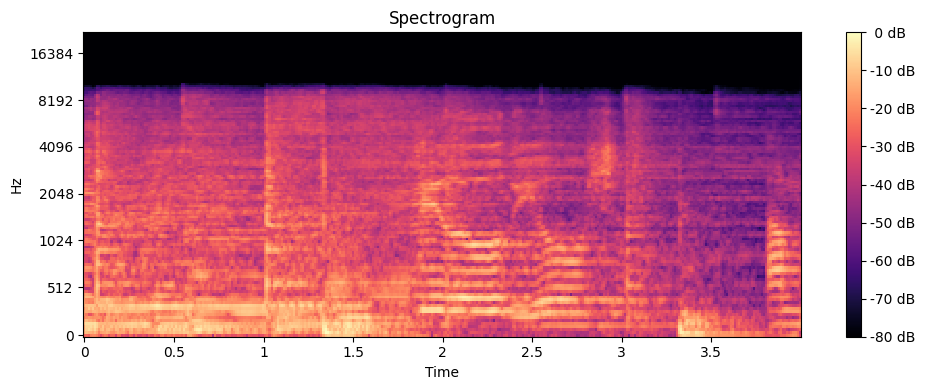

(128, 345)


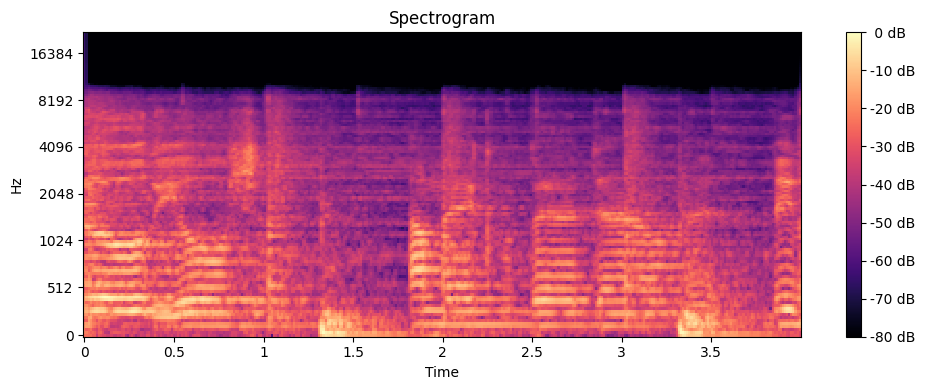

(128, 345)


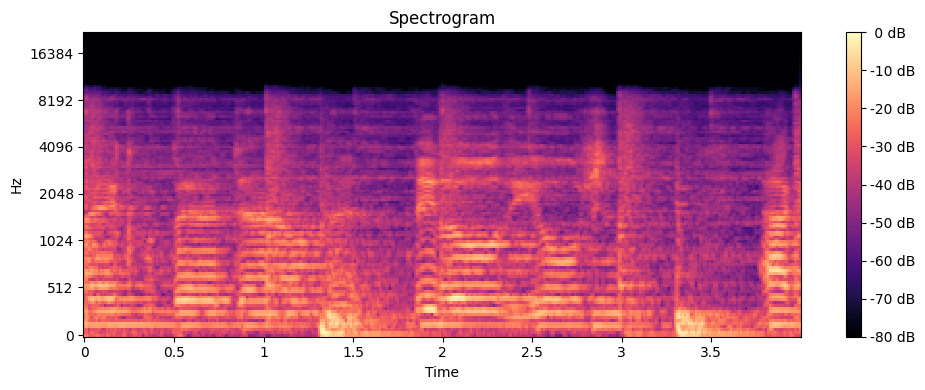

(128, 345)


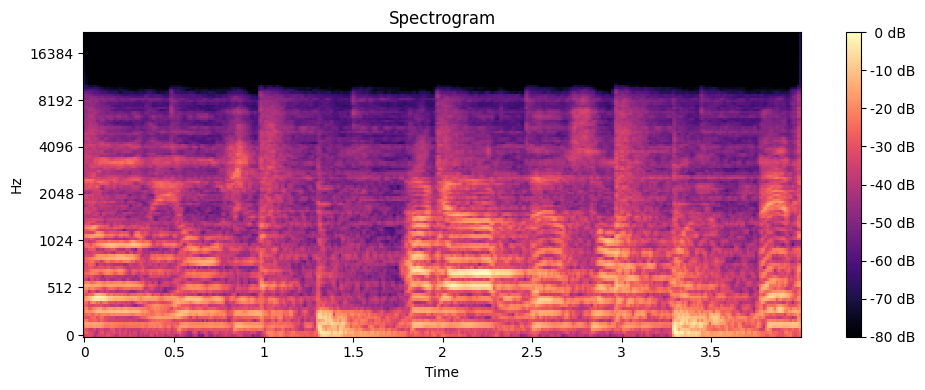

(128, 345)


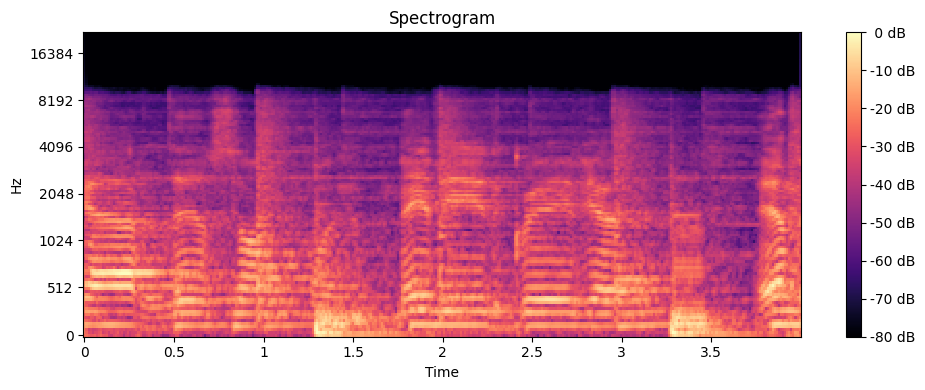

(128, 345)


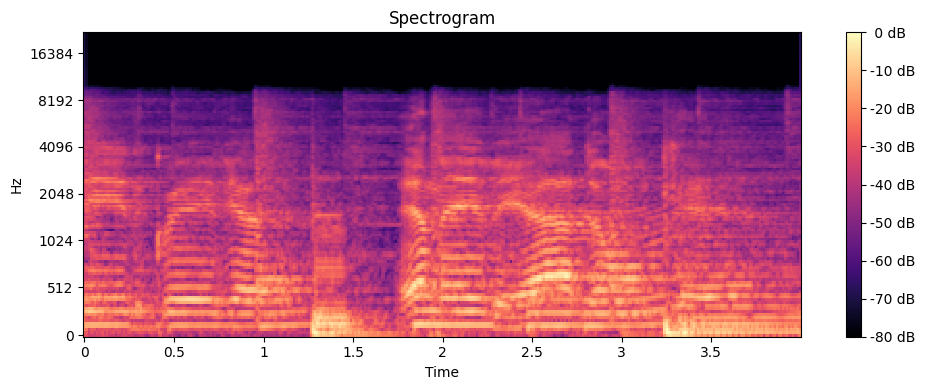

(128, 345)


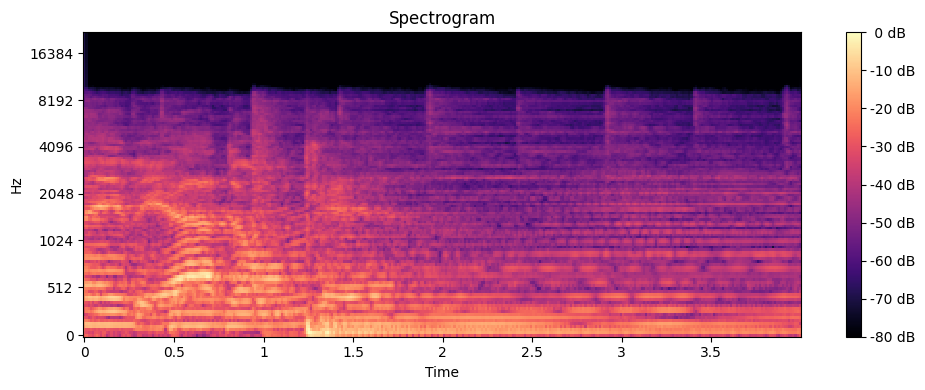

(128, 345)


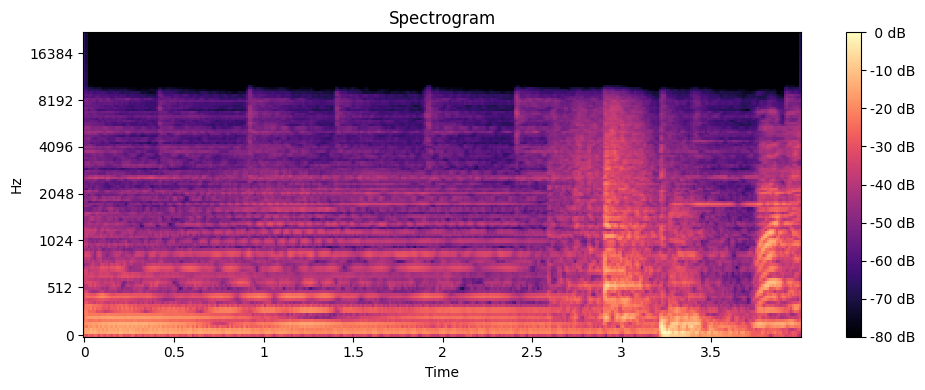

(128, 345)


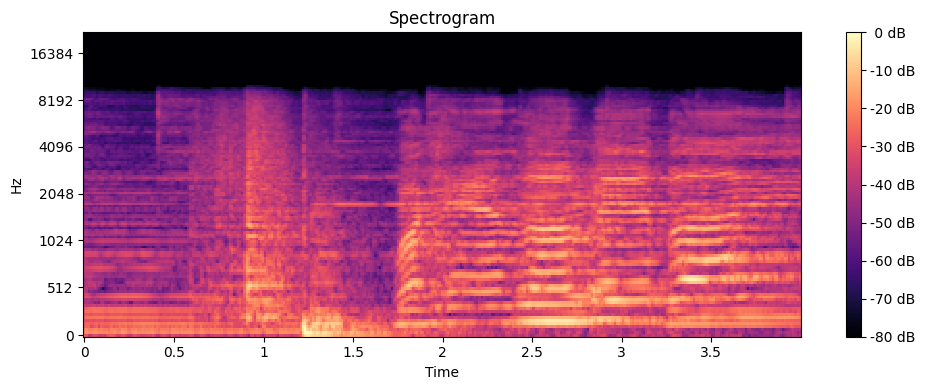

(128, 345)


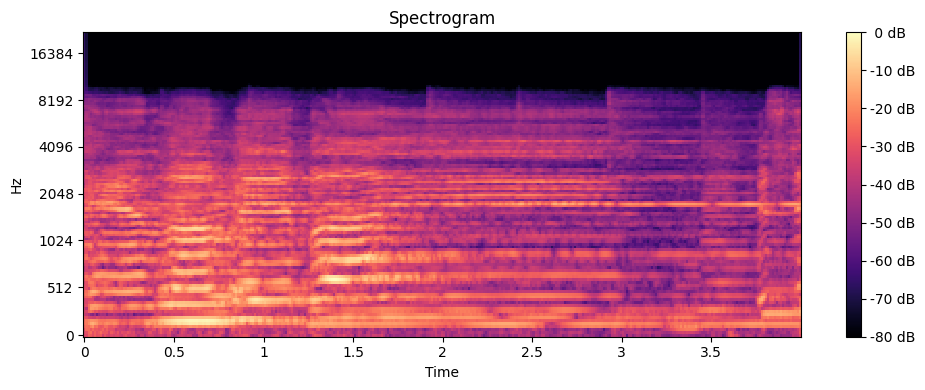

(128, 174)


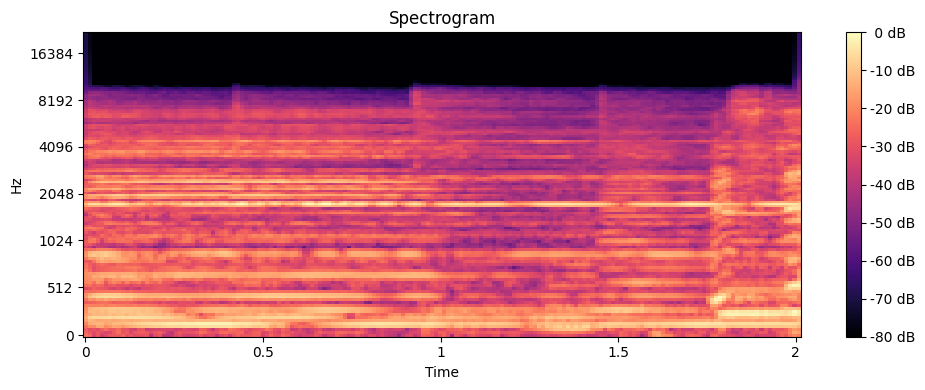

In [11]:
file_name = "/content/drive/MyDrive/music_genre_classification/genres_original/rock/rock.00000.wav"
y,sr = librosa.load(file_name, sr=44100)
plot_melspectrograms_chunk(y,sr)

In [12]:
#data preprocessing 
#define folder structure
data_dir = "/content/drive/MyDrive/music_genre_classification/genres_original"
classes = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']

In [ ]:
from tensorflow.image import resize
#load and preprocess audio data
def load_and_preprocess_data(data_dir, classes, target_shape=(150,150)):
    data=[]
    labels=[]
    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print("processing: ", class_name)
        for filename in os.listdir(class_dir):
            if filename.endswith(".wav"):
                file_path = os.path.join(class_dir, filename)
                audio_data, sample_rate = librosa.load(file_path, sr= None)
                #performing preprocessing
                # Define the duration of each chunk and overlap
                chunk_duration = 4  # duration of each chunk in seconds
                overlap_duration = 2  # overlap duration in seconds
                #convert durations to samples
                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate
                #calculate the number of chunks
                num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples)))+1
                #interate over the chunks
                for i in range(num_chunks):
                    #calculate the start and end sample indices for the current chunk
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples
                    #extra the chunk audio
                    chunk = audio_data[start:end]
                    mel_spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sample_rate)#step234:stft,spectrogram,mel scale
                    #convert to decibels (log scale)
                    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
                    #resize matrix base on provide target shape and add 1 channel
                    mel_spectrogram_db = np.expand_dims(mel_spectrogram_db, axis=-1)
                    mel_spectrogram_db_resize = resize(mel_spectrogram_db, target_shape)
                    #append data to list
                    data.append(mel_spectrogram_db_resize)
                    labels.append(i_class)
    return np.array(data), np.array(labels)

In [14]:
data, labels = load_and_preprocess_data(data_dir, classes)

processing:  blues
processing:  classical
processing:  country
processing:  disco
processing:  hiphop
processing:  jazz
processing:  metal
processing:  pop
processing:  reggae
processing:  rock


In [15]:
while len(labels.shape) > 1:
    labels = np.argmax(labels, axis=-1)
print(labels.shape)

(14990,)


In [16]:
np.save("/content/drive/MyDrive/music_genre_classification/data.npy", data)
np.save("/content/drive/MyDrive/music_genre_classification/labels.npy", labels)